In [10]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision
from tqdm import tqdm

In [11]:
# Load dataset
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 256

# Unlabeled pool of examples
trainset_U0 = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset_U0, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


# # Initial labeled set of examples
L0 = set() 

# budget
B = 10


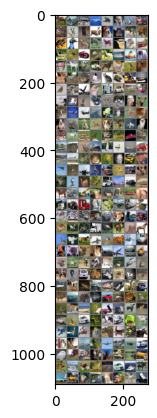

horse car   ship  plane frog  dog   plane truck bird  bird  dog   deer  dog   truck dog   dog   frog  bird  deer  horse horse bird  cat   truck deer  bird  car   bird  horse ship  ship  dog   horse horse deer  car   horse dog   bird  cat   cat   horse frog  dog   cat   frog  horse ship  bird  bird  bird  bird  truck car   horse car   dog   dog   bird  car   deer  cat   dog   deer  cat   plane plane plane frog  cat   deer  cat   dog   frog  dog   deer  dog   deer  plane dog   cat   horse horse bird  truck deer  car   frog  car   cat   deer  ship  ship  plane ship  truck ship  plane deer  frog  frog  dog   car   cat   plane frog  ship  plane truck deer  deer  deer  frog  bird  deer  frog  car   ship  ship  plane horse frog  plane frog  deer  truck car   horse truck car   truck dog   frog  bird  truck cat   deer  car   car   truck truck dog   truck truck bird  horse frog  truck bird  horse dog   horse deer  frog  horse deer  bird  horse plane car   bird  cat   deer  cat   plane plane truc

In [12]:

# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [13]:
# SimCLR implementation

# augmentation
class SimCLRTransform:
    def __init__(self):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(size=32),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __call__(self, x):
        return self.transform(x), self.transform(x)


In [14]:
# ResNet-18 encoder
import torch.nn as nn
import torchvision.models as models

class ResNet18Encoder(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18Encoder, self).__init__()
        self.resnet = models.resnet18(pretrained=False)
        self.resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.resnet.maxpool = nn.Identity()  # Remove maxpool layer for CIFAR-10
        self.resnet.fc = nn.Identity()  # Remove fully connected layer for feature extraction

    def forward(self, x):
        return self.resnet(x)

In [15]:
#  Projection head
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=128, output_dim=128):
        super(ProjectionHead, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [16]:
# NT-Xent loss
def nt_xent_loss(z_i, z_j, temperature=0.5):
    batch_size = z_i.size(0)
    z = torch.cat([z_i, z_j], dim=0)  # Concatenate positive pairs
    
    z = nn.functional.normalize(z, dim=1)  # L2 Norm
    similarity_matrix = torch.matmul(z, z.T)/temperature  # Compute similarity matrix

    mask = torch.eye(2 * batch_size, dtype=torch.bool).to(z.device)
    similarity_matrix = similarity_matrix[~mask].view(2 * batch_size, -1)  # Remove self-similarity

    targets = torch.cat([
        torch.arange(batch_size -1, 2*batch_size -1),
        torch.arange(0, batch_size)
    ]).to(z.device)

    loss = nn.CrossEntropyLoss()(similarity_matrix, targets)
    return loss

In [17]:
# Setup                                                                                                                             
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')         
print(f'Using device: {device}')

Using device: cuda


In [19]:
                                                                                                                                                                                          
# Create dataloader with SimCLR augmentations                                                                                       
simclr_trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                download=False, transform=SimCLRTransform())
simclr_loader = DataLoader(simclr_trainset, batch_size=256, shuffle=True, num_workers=2, drop_last=True)

# Initialize models
encoder = ResNet18Encoder().to(device)
projection_head = ProjectionHead().to(device)

# Optimizer
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(projection_head.parameters()), lr=3e-4)

# Training
num_epochs = 10

for epoch in range(num_epochs):                                                                                                     
    running_loss = 0.0                                                                                                              
    loop = tqdm(simclr_loader, desc=f'Epoch [{epoch+1}/{num_epochs}]', leave=False)                                               
    for (view1, view2), _ in loop:                                                                                                  
        view1, view2 = view1.to(device), view2.to(device)                                                                           
                                                                                                                                    
        h_i = encoder(view1)                                                                                                        
        h_j = encoder(view2)                                                                                                        
        z_i = projection_head(h_i)
        z_j = projection_head(h_j)

        loss = nt_xent_loss(z_i, z_j)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(simclr_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Avg Loss: {avg_loss:.4f}')

# Save encoder weights
torch.save(encoder.state_dict(), 'simclr_encoder.pth')
print('Training complete. Encoder saved.')

Epoch [1/10], Avg Loss: 5.4003


Epoch [2/10], Avg Loss: 5.1891


Epoch [3/10], Avg Loss: 5.1105


Epoch [4/10], Avg Loss: 5.0542


Epoch [5/10], Avg Loss: 5.0150


Epoch [6/10], Avg Loss: 4.9816


Epoch [7/10], Avg Loss: 4.9589


Epoch [8/10], Avg Loss: 4.9402


Epoch [9/10], Avg Loss: 4.9216


Epoch [10/10], Avg Loss: 4.9109
Training complete. Encoder saved.


In [20]:
# Extract Embeddings
encoder.eval()
embeddings = []
labels = []

trainloader = torch.utils.data.DataLoader(trainset_U0, batch_size=batch_size,
                                          shuffle=False, num_workers=2)

with torch.no_grad():
    for images, label in trainloader:                                                                                                   
        images = images.to(device)                                                                                                      
        h = encoder(images)   
        embeddings.append(h.cpu().numpy())
        labels.append(label.numpy())

embeddings = np.vstack(embeddings)
labels = np.hstack(labels)

In [22]:
# Nearest Neighbors for Active Learning
from sklearn.neighbors import NearestNeighbors

nearest_neighbours = NearestNeighbors(n_neighbors=21)
nearest_neighbours.fit(embeddings)
distances, indices = nearest_neighbours.kneighbors(embeddings)

# slice self distances
distances = distances[:, 1:]
indices = indices[:, 1:]

typicallity = np.mean(distances, axis=1)**-1

In [23]:
# K-means clustering on embedding matrix
from sklearn.cluster import KMeans
B = 10 # Budget

kmeans = KMeans(n_clusters=B, random_state=42)
kmeans.fit(embeddings)
cluster_labels = kmeans.labels_

In [24]:
# Querying typical examples
selected_indices = []
for cluster in range(B):
    cluster_indices = np.where(cluster_labels == cluster)[0]
    cluster_typicallity = typicallity[cluster_indices]
    most_typical_index = cluster_indices[np.argmax(cluster_typicallity)]
    selected_indices.append(most_typical_index)
print("Selected indices for labeling:", selected_indices)


Selected indices for labeling: [np.int64(43299), np.int64(7845), np.int64(1009), np.int64(21158), np.int64(22940), np.int64(26107), np.int64(43442), np.int64(25652), np.int64(14731), np.int64(5840)]


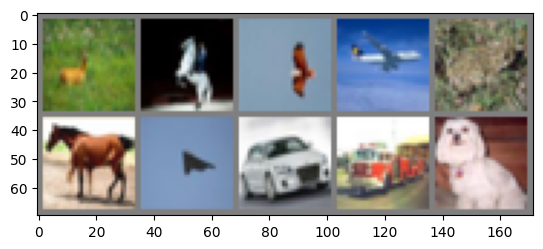

Selected labels: deer horse bird plane frog horse plane car truck dog


In [25]:
# Visualize selected typical examples                                                                                               
selected_images = [trainset_U0[i][0] for i in selected_indices]
selected_labels = [classes[labels[i]] for i in selected_indices]                                                                    
                                                                                                                                    
grid = torchvision.utils.make_grid(torch.stack(selected_images), nrow=5)                                                            
imshow(grid)    
print("Selected labels:", ' '.join(selected_labels))